## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [3]:
df = pd.read_csv('Twitter_Data.csv')

## Basic Inspection

In [4]:
df.shape

(162980, 2)

In [5]:
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [6]:
df.tail()

,clean_text,category
162975,why these 456 crores paid neerav modi not reco...,-1.0
162976,dear rss terrorist payal gawar what about modi...,-1.0
162977,did you cover her interaction forum where she ...,0.0
162978,there big project came into india modi dream p...,0.0
162979,have you ever listen about like gurukul where ...,1.0


In [7]:
df.columns

Index(['clean_text', 'category'], dtype='object')

In [8]:
df.isnull().sum()

clean_text    4
category      7
dtype: int64

## Identify target variable

In [9]:
data = df.dropna(subset=["clean_text", "category"]).copy()

data["category"] = data["category"].astype(int)

data["sentiment"] = data["category"].map({
    -1: "Negative",
     0: "Neutral",
     1: "Positive"
})

In [10]:
print(data["sentiment"].value_counts())

sentiment
Positive    72249
Neutral     55211
Negative    35509
Name: count, dtype: int64


## Text Preprocessing

In [11]:
import re
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stemmer = PorterStemmer()

stop_words = set(ENGLISH_STOP_WORDS) - {
    "not", "no", "never", "neither", "nor", "cannot"
}

def preprocess_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove mentions
    text = re.sub(r"@\w+", " ", text)

    # Remove # symbol but keep hashtag word
    text = re.sub(r"#(\w+)", r"\1", text)

    # Remove punctuation/numbers
    text = re.sub(r"[^a-z\s]", " ", text)

    # Tokenisation
    tokens = re.findall(r"[a-z]+", text)

    # Stopword removal + stemming
    tokens = [
        stemmer.stem(token)
        for token in tokens
        if token not in stop_words
    ]

    return " ".join(tokens)


data["processed_text"] = data["clean_text"].apply(preprocess_text)

In [12]:
display(data[["clean_text", "processed_text"]].head())

,clean_text,processed_text
0,when modi promised “minimum government maximum...,modi promis minimum govern maximum govern expe...
1,talk all the nonsense and continue all the dra...,talk nonsens continu drama vote modi
2,what did just say vote for modi welcome bjp t...,did just say vote modi welcom bjp told rahul m...
3,asking his supporters prefix chowkidar their n...,ask support prefix chowkidar name modi did gre...
4,answer who among these the most powerful world...,answer power world leader today trump putin modi


## TF-IDF

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [14]:
X = data["processed_text"]
y = data["category"]

## 80/20 train-test split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## TF-IDF Vectorization

In [16]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

## Model-1:- Naive Bayes

In [17]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB(alpha=0.5)

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

## Model-2:- Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    C=2.0
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

## Evaluation

In [19]:
from sklearn.metrics import classification_report

print("Naive Bayes")
print(classification_report(
    y_test,
    nb_pred,
    labels=[-1, 0, 1],
    target_names=["Negative", "Neutral", "Positive"]
))

print("Logistic Regression")
print(classification_report(
    y_test,
    lr_pred,
    labels=[-1, 0, 1],
    target_names=["Negative", "Neutral", "Positive"]
))

Naive Bayes
              precision    recall  f1-score   support

    Negative       0.75      0.46      0.57      7102
     Neutral       0.74      0.63      0.68     11042
    Positive       0.65      0.85      0.74     14450

    accuracy                           0.69     32594
   macro avg       0.71      0.65      0.66     32594
weighted avg       0.70      0.69      0.68     32594

Logistic Regression
              precision    recall  f1-score   support

    Negative       0.81      0.71      0.76      7102
     Neutral       0.79      0.88      0.83     11042
    Positive       0.85      0.83      0.84     14450

    accuracy                           0.82     32594
   macro avg       0.82      0.81      0.81     32594
weighted avg       0.82      0.82      0.82     32594



## Confusion Matrix

In [20]:
from sklearn.metrics import confusion_matrix

cm_nb = confusion_matrix(
    y_test,
    nb_pred,
    labels=[-1, 0, 1]
)

print(cm_nb)

[[ 3273   929  2900]
 [  412  6928  3702]
 [  660  1544 12246]]


In [21]:
cm_lr = confusion_matrix(
    y_test,
    lr_pred,
    labels=[-1, 0, 1]
)

print(cm_lr)

[[ 5053   897  1152]
 [  382  9726   934]
 [  779  1645 12026]]


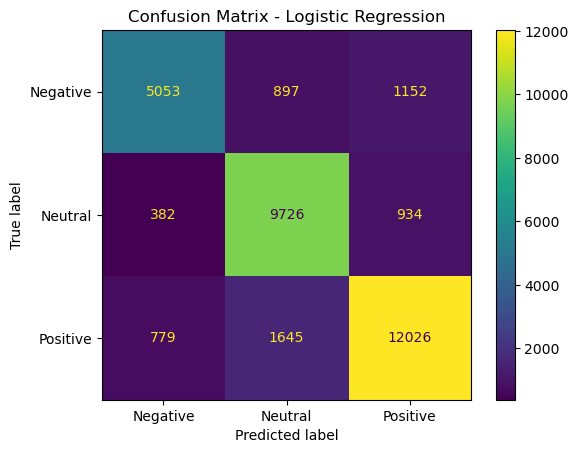

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Negative", "Neutral", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Sentiment distribution bar chart

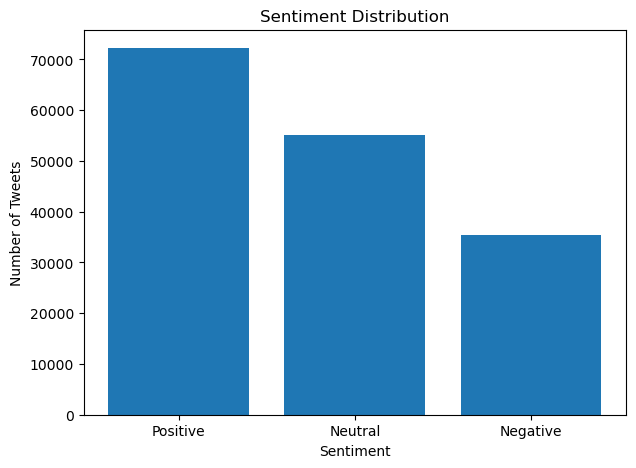

In [23]:
sentiment_order = [
    "Positive",
    "Neutral",
    "Negative"
]

counts = data["sentiment"].value_counts().reindex(sentiment_order)

plt.figure(figsize=(7,5))

plt.bar(
    counts.index,
    counts.values
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

## WordCloud

In [25]:
!pip install wordcloud

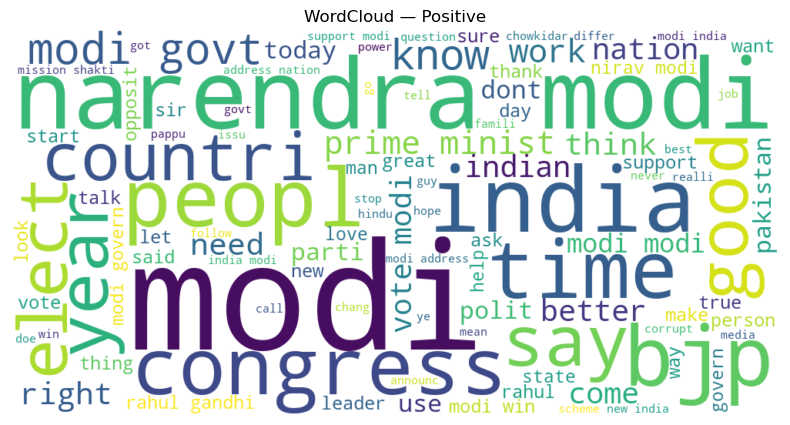

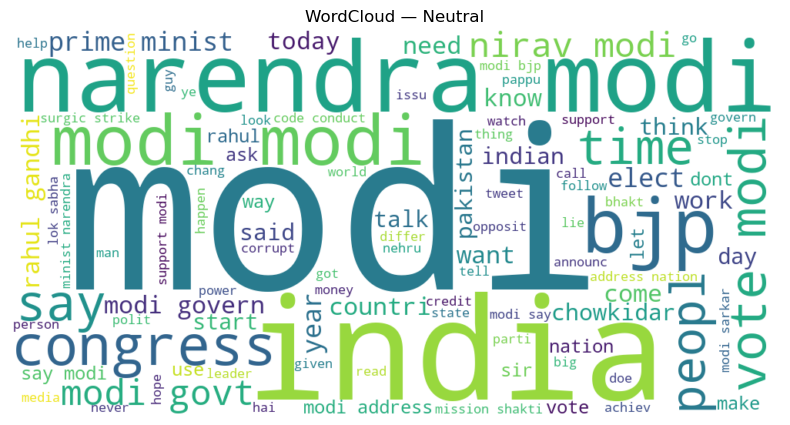

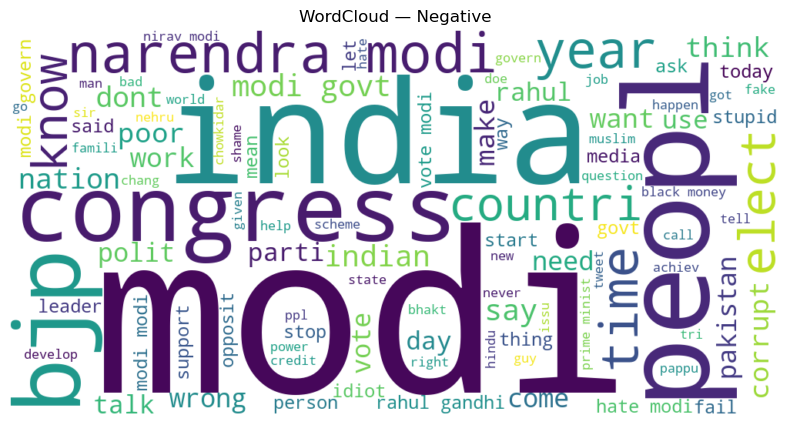

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for sentiment in ["Positive", "Neutral", "Negative"]:

    text = " ".join(
        data.loc[
            data["sentiment"] == sentiment,
            "processed_text"
        ]
    )

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=100
    ).generate(text)

    plt.figure(figsize=(10,5))

    plt.imshow(
        wc,
        interpolation="bilinear"
    )

    plt.axis("off")

    plt.title(
        f"WordCloud — {sentiment}"
    )

    plt.show()

## Error analysis

In [27]:
error_df = data.loc[
    X_test.index,
    ["clean_text", "category", "sentiment"]
].copy()

error_df["predicted_category"] = lr_pred

error_df["predicted_sentiment"] = (
    error_df["predicted_category"]
    .map({
        -1: "Negative",
         0: "Neutral",
         1: "Positive"
    })
)

errors = error_df[
    error_df["category"] !=
    error_df["predicted_category"]
].head(5)

display(
    errors[
        [
            "clean_text",
            "sentiment",
            "predicted_sentiment"
        ]
    ]
)

,clean_text,sentiment,predicted_sentiment
148778,you are from turkey and reading this read the ...,Negative,Neutral
31461,modis long silence election rallies intriguing...,Positive,Negative
56954,lol modi never mentioned anything about nehru ...,Positive,Neutral
14462,hello modi sir big supporter bjp but one big p...,Neutral,Positive
13846,founder tak nahi choda inki ghatiya soch yet a...,Negative,Neutral


## final Conclusion

Two machine-learning classifiers, Multinomial Naive Bayes and Logistic Regression, were trained using TF-IDF features and an 80/20 train-test split. Logistic Regression performed better, achieving approximately 81.98% accuracy and 81.85% weighted F1-score, compared with 68.78% accuracy and 67.94% weighted F1-score for Multinomial Naive Bayes. Therefore, Logistic Regression is the better-performing model for this dataset. This sentiment-analysis system could be used for public-opinion monitoring, customer feedback analysis, social-media monitoring and understanding reactions to products, services, events or policies.